In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [4]:
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
print('All libraries imported')

All libraries imported


In [5]:
data = load_diabetes()
print('Feature names:', data.feature_names)
print('Target: disease progression score')


Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Target: disease progression score


In [6]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
print('Shape:', df.shape)

Shape: (442, 11)


In [7]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [8]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [9]:
df.isnull().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

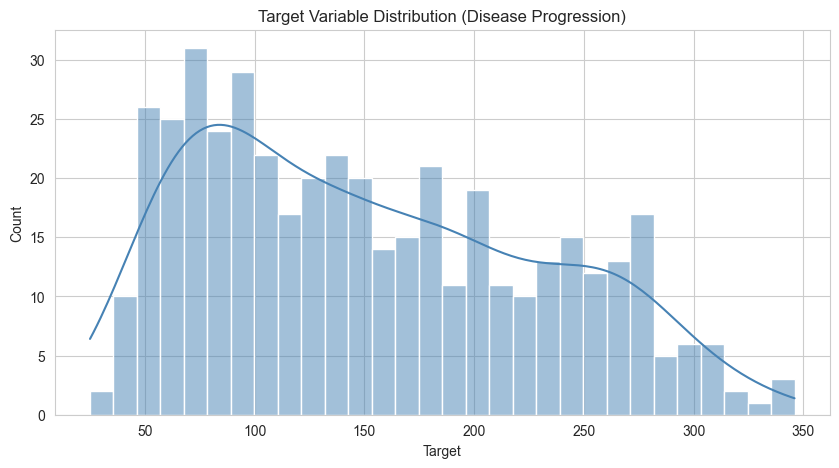

In [10]:
sns.histplot(df['target'], kde=True, color='steelblue', bins=30)
plt.title('Target Variable Distribution (Disease Progression)')
plt.xlabel('Target')
plt.show()

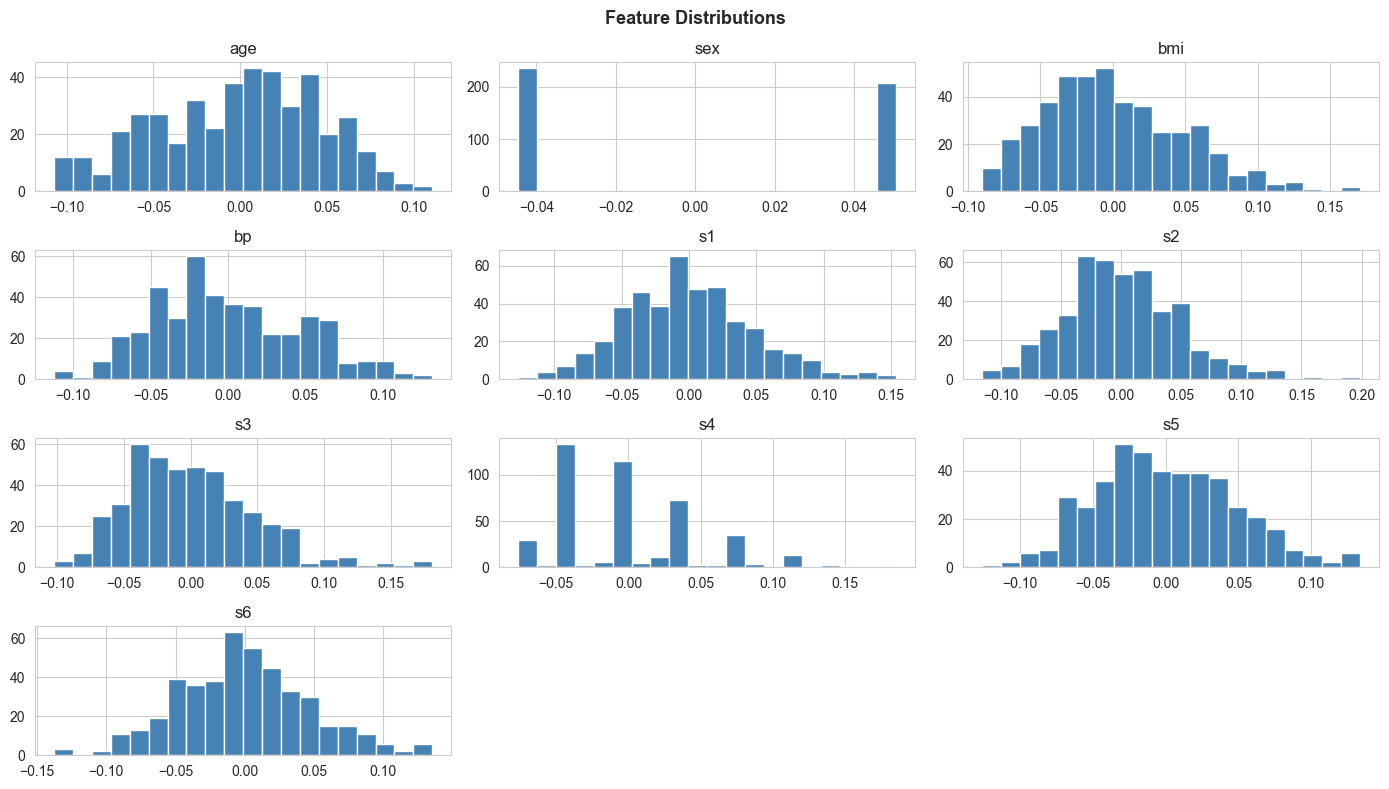

In [11]:
df.drop(columns='target').hist(bins=20, figsize=(14, 8), color='steelblue', edgecolor='white')
plt.suptitle('Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

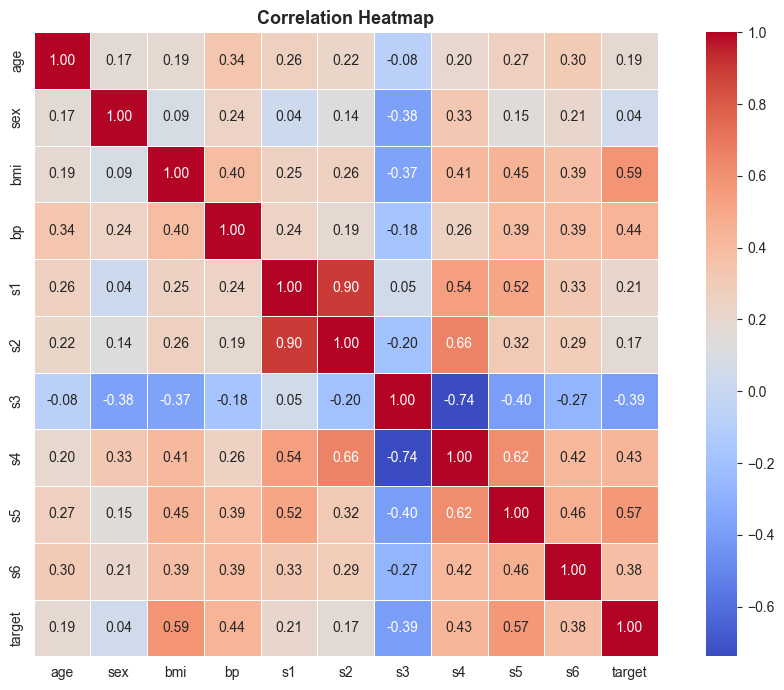

In [12]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
df.corr()['target'].drop('target').sort_values(ascending=False)

bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
s3    -0.394789
Name: target, dtype: float64

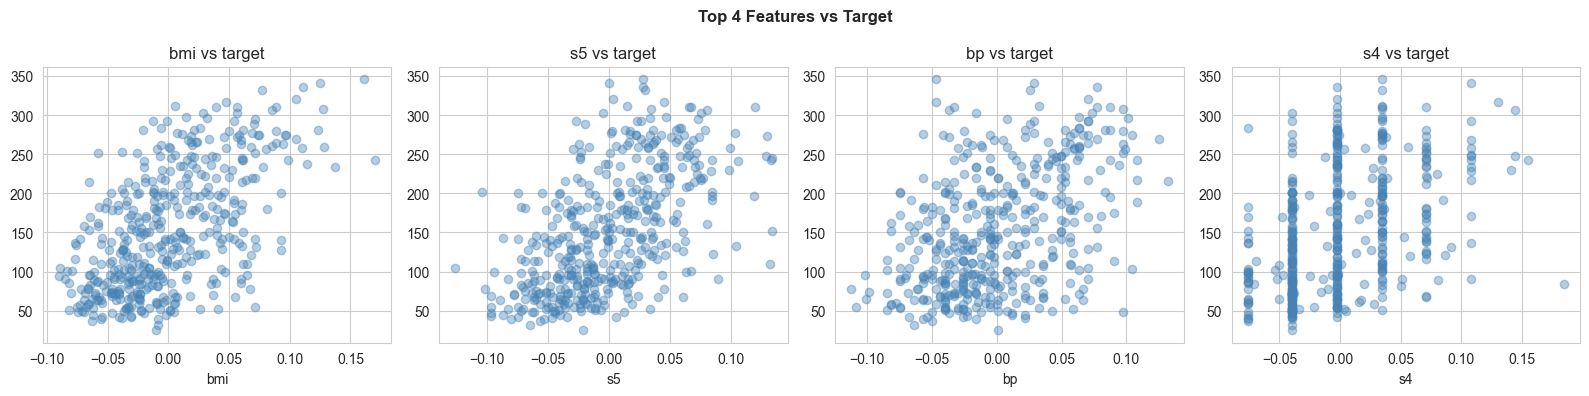

In [14]:
top_features = df.corr()['target'].drop('target').abs().sort_values(ascending=False).index[:4]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, feat in enumerate(top_features):
    axes[i].scatter(df[feat], df['target'], alpha=0.4, color='steelblue')
    axes[i].set_title(f'{feat} vs target')
    axes[i].set_xlabel(feat)
plt.suptitle('Top 4 Features vs Target', fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
X = df.drop(columns='target')
y = df['target']
print('Features shape:', X.shape)
print('Target shape  :', y.shape)

Features shape: (442, 10)
Target shape  : (442,)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 353 | Test: 89


In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('Features scaled')

Features scaled


In [19]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)
X_train_scaled.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,1.498365,1.061370,0.219902,1.138874,0.728473,1.055893,-0.824451,0.711038,0.547482,-0.061449
1,-0.228858,1.061370,-0.419366,-0.710591,-0.424929,0.272425,-1.529791,1.484286,-0.019757,0.367236
2,0.085182,-0.942179,1.018987,1.992473,-0.309589,-0.326699,-0.119111,-0.062210,0.331237,-0.318660
3,-0.621409,-0.942179,-0.784662,-0.639458,-1.174640,-1.215508,0.664600,-0.835458,-1.069682,-2.719299
4,-0.542899,-0.942179,-1.423930,-1.706457,-0.799784,-1.110167,1.291569,-1.608706,-0.802859,-0.918820


In [20]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
print('Linear Regression trained')

Linear Regression trained


In [21]:
y_pred_lr = lr.predict(X_test_scaled)
y_pred_lr[:5]

array([139.5475584 , 179.51720835, 134.03875572, 291.41702925,
       123.78965872])

In [22]:
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print('=== Linear Regression ===')
print(f'  MAE  : {mae_lr:.4f}')
print(f'  RMSE : {rmse_lr:.4f}')
print(f'  R²   : {r2_lr:.4f}')

=== Linear Regression ===
  MAE  : 42.7941
  RMSE : 53.8534
  R²   : 0.4526


In [23]:
cv_lr = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='r2')
print(f'Cross-Val R² (5-fold): {cv_lr.mean():.4f} ± {cv_lr.std():.4f}')

Cross-Val R² (5-fold): 0.4493 ± 0.1441


In [24]:
lr_coef = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr.coef_})
lr_coef = lr_coef.sort_values('Coefficient', key=abs, ascending=False)
lr_coef

,Feature,Coefficient
4,s1,-44.448856
8,s5,35.161195
2,bmi,25.607121
5,s2,24.640954
3,bp,16.828872
7,s4,13.138784
1,sex,-11.511809
6,s3,7.676978
9,s6,2.351364
0,age,1.753758


In [25]:
print('Ridge Regression — L2 regularization')
print('Penalty: α × Σ(coefficient²)')

Ridge Regression — L2 regularization
Penalty: α × Σ(coefficient²)


In [26]:
alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 500.0]
ridge_r2_scores = []

for a in alphas:
    r = Ridge(alpha=a)
    r.fit(X_train_scaled, y_train)
    score = r2_score(y_test, r.predict(X_test_scaled))
    ridge_r2_scores.append(score)
    print(f'  alpha={a:>7} → R²={score:.4f}')

  alpha=   0.01 → R²=0.4526
  alpha=    0.1 → R²=0.4528
  alpha=    1.0 → R²=0.4541
  alpha=   10.0 → R²=0.4572
  alpha=  100.0 → R²=0.4605
  alpha=  500.0 → R²=0.4109


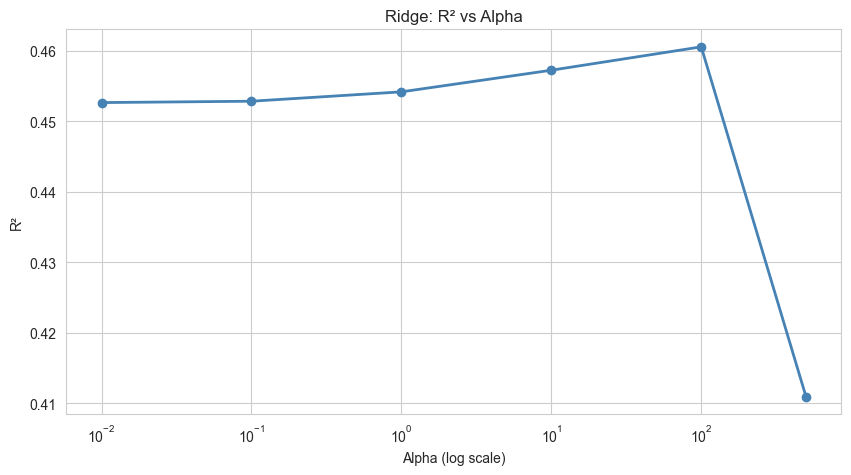

In [27]:
plt.plot(alphas, ridge_r2_scores, marker='o', color='steelblue', linewidth=2)
plt.xscale('log')
plt.title('Ridge: R² vs Alpha')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R²')
plt.grid(True)
plt.show()

In [28]:
best_ridge_alpha = alphas[np.argmax(ridge_r2_scores)]
print(f'Best Ridge alpha: {best_ridge_alpha}')

Best Ridge alpha: 100.0


In [29]:
ridge_best = Ridge(alpha=best_ridge_alpha)
ridge_best.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_best.predict(X_test_scaled)
print(' Best Ridge model trained')

 Best Ridge model trained


In [30]:
mae_ridge  = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge   = r2_score(y_test, y_pred_ridge)

print(f'=== Ridge Regression (alpha={best_ridge_alpha}) ===')
print(f'  MAE  : {mae_ridge:.4f}')
print(f'  RMSE : {rmse_ridge:.4f}')
print(f'  R²   : {r2_ridge:.4f}')

=== Ridge Regression (alpha=100.0) ===
  MAE  : 43.2507
  RMSE : 53.4624
  R²   : 0.4605


In [31]:
cv_ridge = cross_val_score(ridge_best, X_train_scaled, y_train, cv=5, scoring='r2')
print(f'Cross-Val R² (5-fold): {cv_ridge.mean():.4f} ± {cv_ridge.std():.4f}')

Cross-Val R² (5-fold): 0.4509 ± 0.1093


In [32]:
ridge_coef = pd.DataFrame({'Feature': X.columns, 'Coefficient': ridge_best.coef_})
ridge_coef = ridge_coef.sort_values('Coefficient', key=abs, ascending=False)
ridge_coef

,Feature,Coefficient
2,bmi,21.561936
8,s5,16.477222
3,bp,13.926917
6,s3,-9.059339
1,sex,-8.168076
7,s4,6.683867
9,s6,4.688816
5,s2,-4.087197
4,s1,-2.898262
0,age,2.093789


In [33]:
print('Lasso Regression — L1 regularization')
print('Penalty: α × Σ|coefficient|')

Lasso Regression — L1 regularization
Penalty: α × Σ|coefficient|


In [34]:
lasso_alphas = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
lasso_r2_scores = []

for a in lasso_alphas:
    l = Lasso(alpha=a)
    l.fit(X_train_scaled, y_train)
    score = r2_score(y_test, l.predict(X_test_scaled))
    n_zero = np.sum(l.coef_ == 0)
    lasso_r2_scores.append(score)
    print(f'  alpha={a:<6} → R²={score:.4f} | Features removed: {n_zero}')

  alpha=0.001  → R²=0.4526 | Features removed: 0
  alpha=0.01   → R²=0.4529 | Features removed: 0
  alpha=0.05   → R²=0.4542 | Features removed: 0
  alpha=0.1    → R²=0.4555 | Features removed: 0
  alpha=0.5    → R²=0.4607 | Features removed: 1
  alpha=1.0    → R²=0.4669 | Features removed: 1


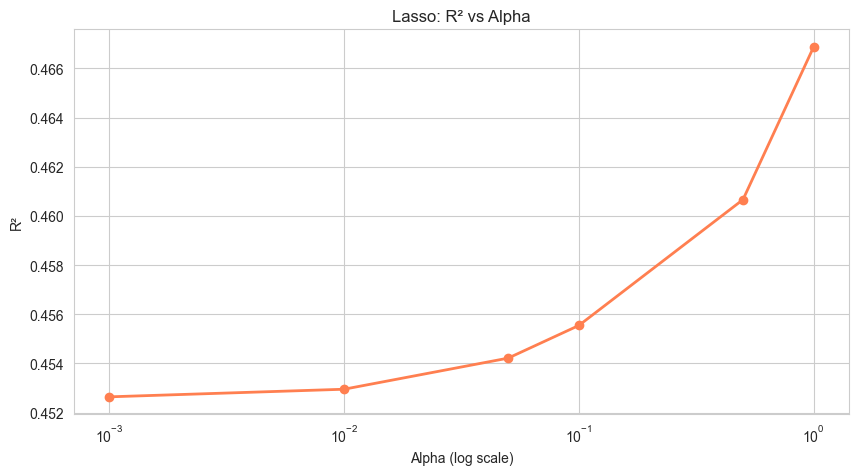

In [35]:
plt.plot(lasso_alphas, lasso_r2_scores, marker='o', color='coral', linewidth=2)
plt.xscale('log')
plt.title('Lasso: R² vs Alpha')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R²')
plt.grid(True)
plt.show()

In [36]:
best_lasso_alpha = lasso_alphas[np.argmax(lasso_r2_scores)]
print(f'Best Lasso alpha: {best_lasso_alpha}')

Best Lasso alpha: 1.0


In [37]:
lasso_best = Lasso(alpha=best_lasso_alpha)
lasso_best.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_best.predict(X_test_scaled)
print('Best Lasso model trained')

Best Lasso model trained


In [38]:
mae_lasso  = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso   = r2_score(y_test, y_pred_lasso)

print(f'=== Lasso Regression (alpha={best_lasso_alpha}) ===')
print(f'  MAE  : {mae_lasso:.4f}')
print(f'  RMSE : {rmse_lasso:.4f}')
print(f'  R²   : {r2_lasso:.4f}')

=== Lasso Regression (alpha=1.0) ===
  MAE  : 42.8030
  RMSE : 53.1467
  R²   : 0.4669


In [39]:
cv_lasso = cross_val_score(lasso_best, X_train_scaled, y_train, cv=5, scoring='r2')
print(f'Cross-Val R² (5-fold): {cv_lasso.mean():.4f} ± {cv_lasso.std():.4f}')

Cross-Val R² (5-fold): 0.4541 ± 0.1253


In [40]:
lasso_coef = pd.DataFrame({'Feature': X.columns, 'Coefficient': lasso_best.coef_})
lasso_coef = lasso_coef.sort_values('Coefficient', key=abs, ascending=False)
lasso_coef

,Feature,Coefficient
2,bmi,26.219225
8,s5,22.636465
3,bp,15.657314
1,sex,-9.297519
6,s3,-9.024087
4,s1,-8.228172
7,s4,3.420861
9,s6,2.098647
0,age,0.687032
5,s2,-0.000000


In [41]:
removed = lasso_coef[lasso_coef['Coefficient'] == 0.0]
kept    = lasso_coef[lasso_coef['Coefficient'] != 0.0]
print(f'Features KEPT    ({len(kept)}) : {kept["Feature"].tolist()}')
print(f'Features REMOVED ({len(removed)}): {removed["Feature"].tolist()}')

Features KEPT    (9) : ['bmi', 's5', 'bp', 'sex', 's3', 's1', 's4', 's6', 'age']
Features REMOVED (1): ['s2']


In [42]:
results = pd.DataFrame({
    'Model' : ['Linear Regression', f'Ridge (α={best_ridge_alpha})', f'Lasso (α={best_lasso_alpha})'],
    'MAE'   : [round(mae_lr, 4),    round(mae_ridge, 4),    round(mae_lasso, 4)],
    'RMSE'  : [round(rmse_lr, 4),   round(rmse_ridge, 4),   round(rmse_lasso, 4)],
    'R²'    : [round(r2_lr, 4),     round(r2_ridge, 4),     round(r2_lasso, 4)]
})
results

,Model,MAE,RMSE,R²
0,Linear Regression,42.7941,53.8534,0.4526
1,Ridge (α=100.0),43.2507,53.4624,0.4605
2,Lasso (α=1.0),42.8030,53.1467,0.4669


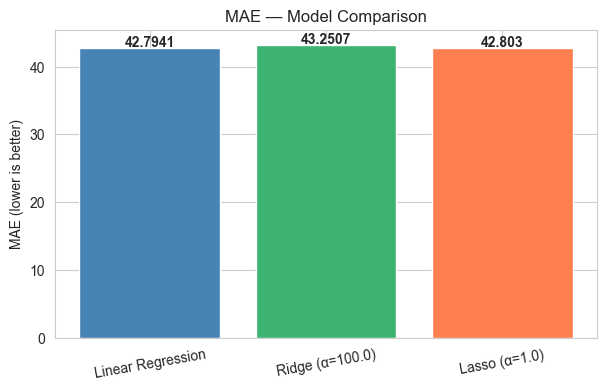

In [43]:
colors = ['steelblue', 'mediumseagreen', 'coral']
plt.figure(figsize=(7, 4))
plt.bar(results['Model'], results['MAE'], color=colors, edgecolor='white')
plt.title('MAE — Model Comparison')
plt.ylabel('MAE (lower is better)')
for i, v in enumerate(results['MAE']):
    plt.text(i, v + 0.2, str(v), ha='center', fontweight='bold')
plt.xticks(rotation=10)
plt.show()

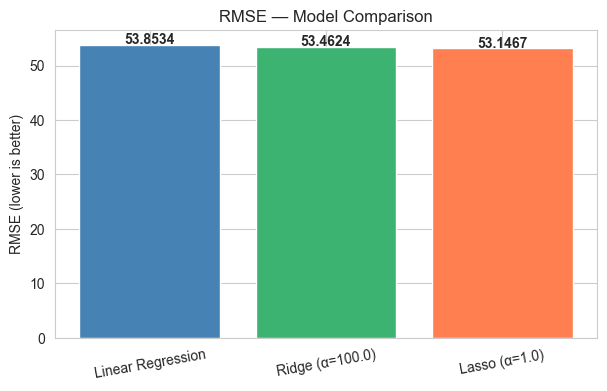

In [44]:
plt.figure(figsize=(7, 4))
plt.bar(results['Model'], results['RMSE'], color=colors, edgecolor='white')
plt.title('RMSE — Model Comparison')
plt.ylabel('RMSE (lower is better)')
for i, v in enumerate(results['RMSE']):
    plt.text(i, v + 0.2, str(v), ha='center', fontweight='bold')
plt.xticks(rotation=10)
plt.show()

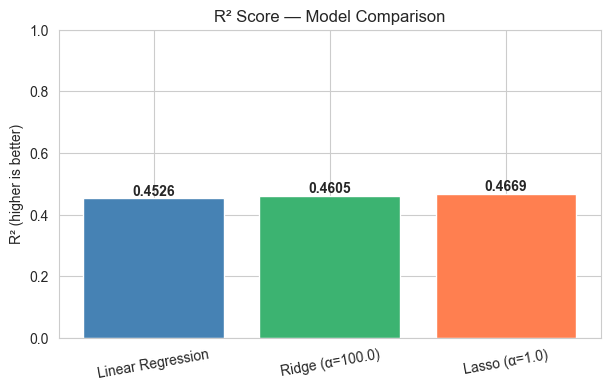

In [45]:
plt.figure(figsize=(7, 4))
plt.bar(results['Model'], results['R²'], color=colors, edgecolor='white')
plt.title('R² Score — Model Comparison')
plt.ylabel('R² (higher is better)')
plt.ylim(0, 1)
for i, v in enumerate(results['R²']):
    plt.text(i, v + 0.01, str(v), ha='center', fontweight='bold')
plt.xticks(rotation=10)
plt.show()

In [46]:
coef_compare = pd.DataFrame({
    'Feature'           : X.columns,
    'Linear Regression' : lr.coef_,
    'Ridge'             : ridge_best.coef_,
    'Lasso'             : lasso_best.coef_
})
coef_compare

,Feature,Linear Regression,Ridge,Lasso
0,age,1.753758,2.093789,0.687032
1,sex,-11.511809,-8.168076,-9.297519
2,bmi,25.607121,21.561936,26.219225
3,bp,16.828872,13.926917,15.657314
4,s1,-44.448856,-2.898262,-8.228172
5,s2,24.640954,-4.087197,-0.000000
6,s3,7.676978,-9.059339,-9.024087
7,s4,13.138784,6.683867,3.420861
8,s5,35.161195,16.477222,22.636465
9,s6,2.351364,4.688816,2.098647


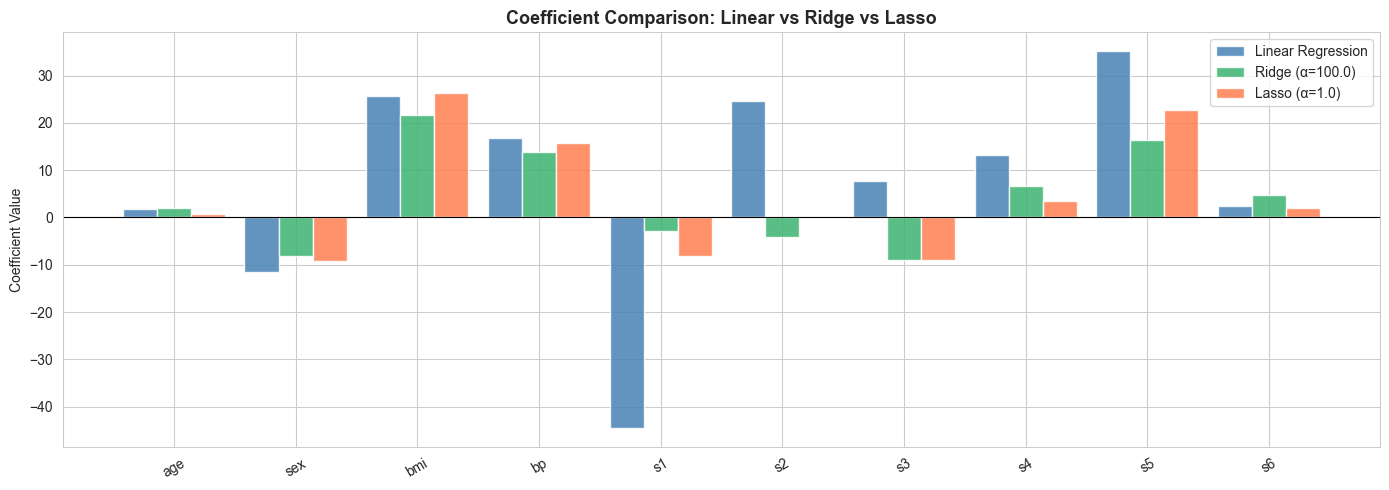

In [47]:
x = np.arange(len(X.columns))
width = 0.28

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width, lr.coef_,         width, label='Linear Regression',          color='steelblue',     alpha=0.85)
ax.bar(x,         ridge_best.coef_, width, label=f'Ridge (α={best_ridge_alpha})', color='mediumseagreen', alpha=0.85)
ax.bar(x + width, lasso_best.coef_, width, label=f'Lasso (α={best_lasso_alpha})', color='coral',         alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(X.columns, rotation=30)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Coefficient Comparison: Linear vs Ridge vs Lasso', fontsize=13, fontweight='bold')
ax.set_ylabel('Coefficient Value')
ax.legend()
plt.tight_layout()
plt.show()

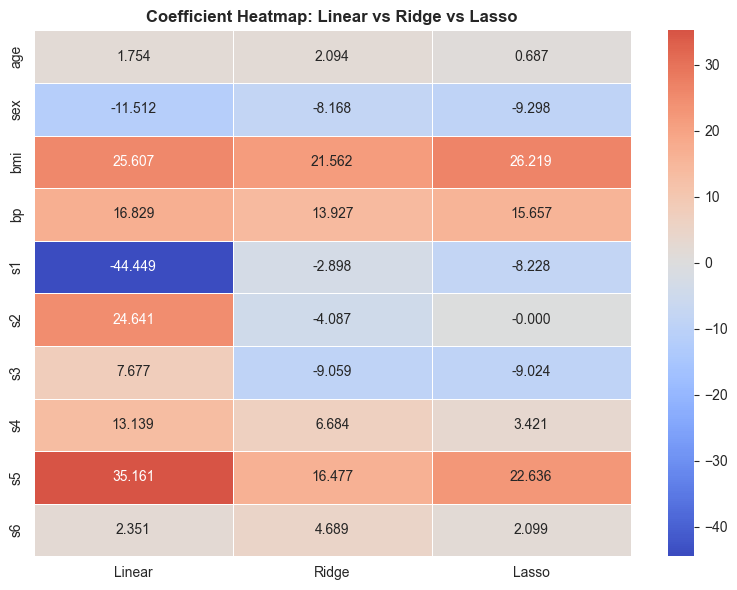

In [48]:
coef_heat = pd.DataFrame({
    'Linear': lr.coef_,
    'Ridge' : ridge_best.coef_,
    'Lasso' : lasso_best.coef_
}, index=X.columns)

plt.figure(figsize=(8, 6))
sns.heatmap(coef_heat, annot=True, fmt='.3f', cmap='coolwarm', linewidths=0.5, center=0)
plt.title('Coefficient Heatmap: Linear vs Ridge vs Lasso', fontweight='bold')
plt.tight_layout()
plt.show()

In [49]:
print('Lasso Feature Selection Summary:')
for feat, coef in zip(X.columns, lasso_best.coef_):
    status = '← REMOVED (zero)' if coef == 0 else '← kept'
    print(f'  {feat:5s}: {coef:>10.4f}  {status}')

Lasso Feature Selection Summary:
  age  :     0.6870  ← kept
  sex  :    -9.2975  ← kept
  bmi  :    26.2192  ← kept
  bp   :    15.6573  ← kept
  s1   :    -8.2282  ← kept
  s2   :    -0.0000  ← REMOVED (zero)
  s3   :    -9.0241  ← kept
  s4   :     3.4209  ← kept
  s5   :    22.6365  ← kept
  s6   :     2.0986  ← kept


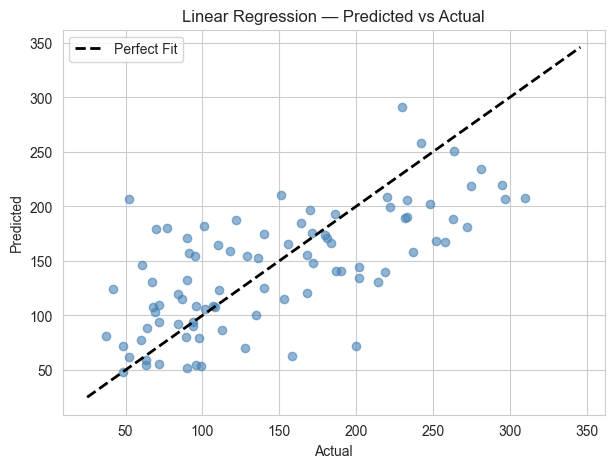

In [50]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_lr, alpha=0.6, color='steelblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Perfect Fit')
plt.title('Linear Regression — Predicted vs Actual')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
plt.show()

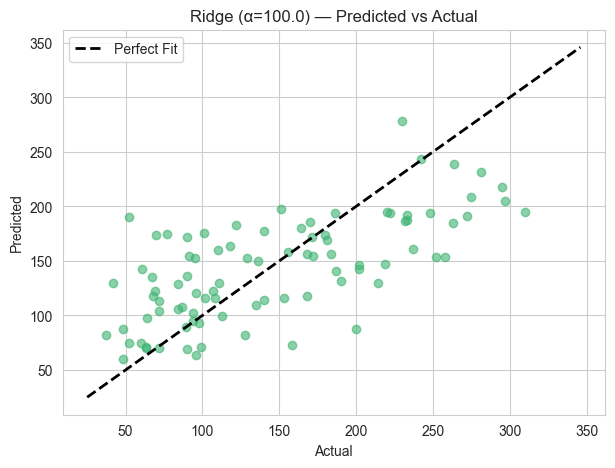

In [51]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_ridge, alpha=0.6, color='mediumseagreen')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Perfect Fit')
plt.title(f'Ridge (α={best_ridge_alpha}) — Predicted vs Actual')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
plt.show()

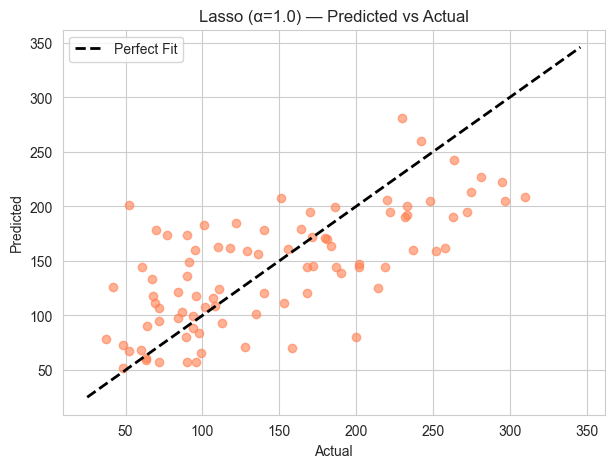

In [52]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_lasso, alpha=0.6, color='coral')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Perfect Fit')
plt.title(f'Lasso (α={best_lasso_alpha}) — Predicted vs Actual')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
plt.show()

In [53]:
res_lr    = y_test - y_pred_lr
res_ridge = y_test - y_pred_ridge
res_lasso = y_test - y_pred_lasso

print(f'LR    residual mean: {res_lr.mean():.4f}')
print(f'Ridge residual mean: {res_ridge.mean():.4f}')
print(f'Lasso residual mean: {res_lasso.mean():.4f}')

LR    residual mean: 3.9128
Ridge residual mean: 2.5440
Lasso residual mean: 3.4724


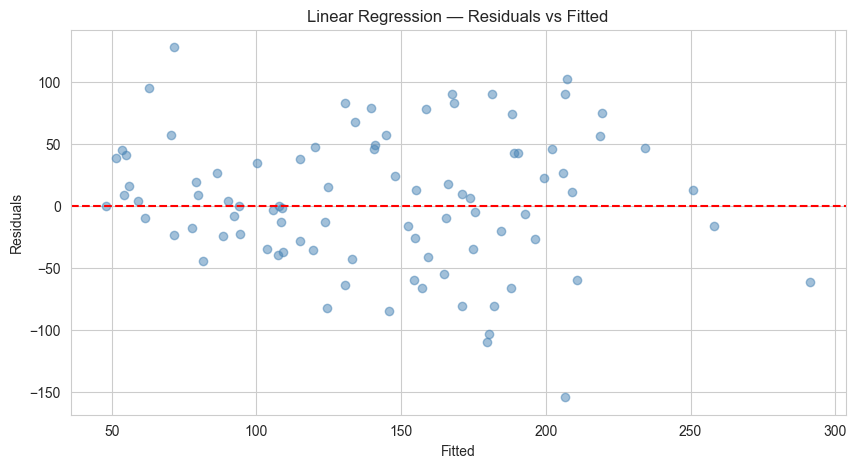

In [54]:
plt.scatter(y_pred_lr, res_lr, alpha=0.5, color='steelblue')
plt.axhline(0, color='red', linestyle='--')
plt.title('Linear Regression — Residuals vs Fitted')
plt.xlabel('Fitted')
plt.ylabel('Residuals')
plt.show()

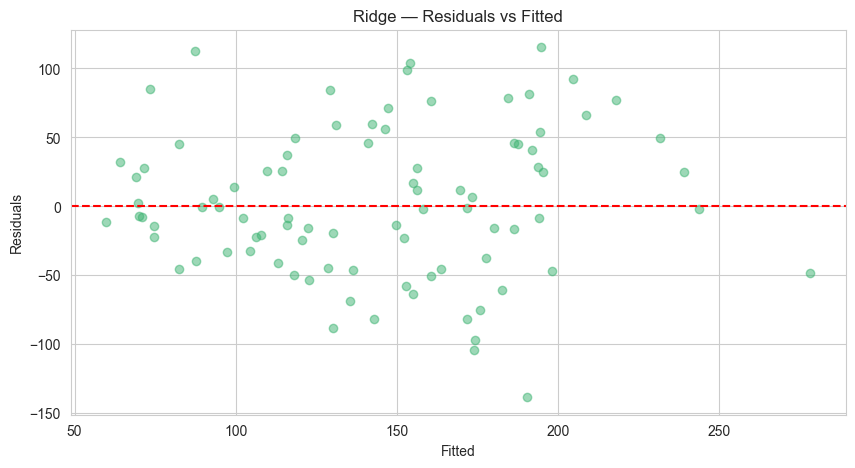

In [55]:
plt.scatter(y_pred_ridge, res_ridge, alpha=0.5, color='mediumseagreen')
plt.axhline(0, color='red', linestyle='--')
plt.title('Ridge — Residuals vs Fitted')
plt.xlabel('Fitted')
plt.ylabel('Residuals')
plt.show()

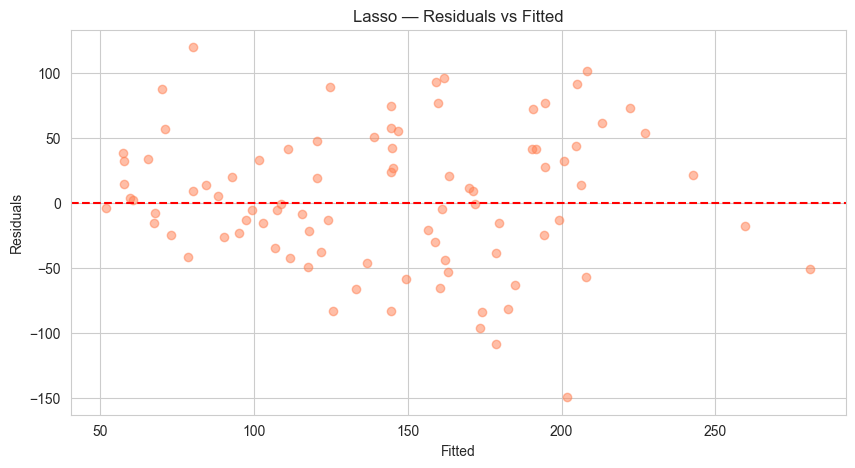

In [56]:
plt.scatter(y_pred_lasso, res_lasso, alpha=0.5, color='coral')
plt.axhline(0, color='red', linestyle='--')
plt.title('Lasso — Residuals vs Fitted')
plt.xlabel('Fitted')
plt.ylabel('Residuals')
plt.show()

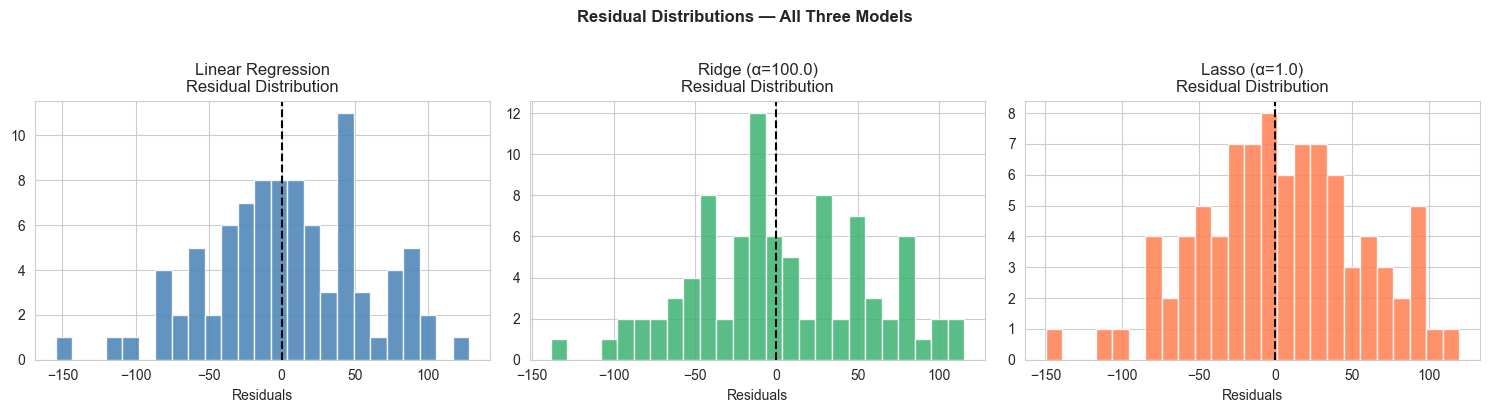

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, res, label, color in zip(
    axes,
    [res_lr, res_ridge, res_lasso],
    ['Linear Regression', f'Ridge (α={best_ridge_alpha})', f'Lasso (α={best_lasso_alpha})'],
    ['steelblue', 'mediumseagreen', 'coral']
):
    ax.hist(res, bins=25, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='black', linestyle='--')
    ax.set_title(f'{label}\nResidual Distribution')
    ax.set_xlabel('Residuals')

plt.suptitle('Residual Distributions — All Three Models', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [59]:
print('Model Performance Summary\n')
print(results.to_string(index=False))
print()
best_r2_idx   = results['R²'].idxmax()
best_mae_idx  = results['MAE'].idxmin()
print(f'Best R²  → {results.loc[best_r2_idx,  "Model"]}')
print(f'Best MAE → {results.loc[best_mae_idx, "Model"]}')

Model Performance Summary

            Model     MAE    RMSE     R²
Linear Regression 42.7941 53.8534 0.4526
  Ridge (α=100.0) 43.2507 53.4624 0.4605
    Lasso (α=1.0) 42.8030 53.1467 0.4669

Best R²  → Lasso (α=1.0)
Best MAE → Linear Regression
